In [ ]:
# Importing standard libraries.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset

In [ ]:
# We load the dataset from hugging face datasets library.
# We work with the standard california_housing dataset.
dataset = load_dataset("gvlassis/california_housing")
# Printing to see what the columns and rows look like.
# Each row is 1 sample, each column is 1 feature.
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal'],
        num_rows: 16640
    })
    validation: Dataset({
        features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal'],
        num_rows: 2000
    })
})


In [ ]:
# We convert these to a Pandas dataframe in order to make work more efficient.
dataset_dfpd_train = dataset["train"].to_pandas()
dataset_dfpd_val = dataset["validation"].to_pandas()
dataset_dfpd_test = dataset["test"].to_pandas()
# We print these splits to see the approximate numeric content of each dataset.
# We see 9 features for each as expected.
# Train : 16640, Val : 2000, Test : 2000 is no. of samples, as expected.
print(dataset_dfpd_train)
print(dataset_dfpd_val)
print(dataset_dfpd_test)

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
16635  4.9359      15.0  6.525316   1.034810       781.0  2.471519     35.30   
16636  2.5172      16.0  6.150470   1.095611      1325.0  2.076803     35.31   
16637  3.5870      20.0  6.027397   1.076712       996.0  2.728767     35.33   
16638  3.2112      20.0  6.517308   1.353846      1309.0  2.517308     35.60   
16639  3.1818      36.0  6.510067   1.057047       850.0  2.852349     35.29   

       Longitude  MedHouseVal  
0      

In [ ]:
# In order to further perform matrix operation on these;
# We need to convert the numeric content into numpy format.
# First, we filter out the numeric content from the given dataframe.
dataset_dfpd_train = dataset_dfpd_train.select_dtypes(include = [np.number])
dataset_dfpd_val = dataset_dfpd_val.select_dtypes(include = [np.number])
dataset_dfpd_test = dataset_dfpd_test.select_dtypes(include = [np.number])
# the .select_dtype() argument is a selection tool.
# Whatever the argument is passed inside, along with an indicator of include or exclude;
# tells it what specific data entries do we need to keep from our main dataframe.
trainset = dataset_dfpd_train.to_numpy()
valset = dataset_dfpd_val.to_numpy()
testset = dataset_dfpd_test.to_numpy()
# Now we convert these into numpy tensors.
# Let's check their shapes.
print(trainset.shape)
print(valset.shape)
print(testset.shape)
# Now, we standardize their values in order to prevent overflow.
# We use the Z - score normalizer for our purpose.
ar_mean_t = np.mean(trainset, axis = 0)
std_dev_t = np.sqrt(np.mean((trainset - ar_mean_t) ** 2, axis = 0))
trainset = (trainset - ar_mean_t) / std_dev_t
# Normalized trainset.
ar_mean_v = np.mean(valset, axis = 0)
std_dev_v = np.sqrt(np.mean((valset - ar_mean_v) ** 2, axis = 0))
valset = (valset - ar_mean_v) / std_dev_v
# Normalized validation set.
ar_mean_test = np.mean(testset, axis = 0)
std_dev_test = np.sqrt(np.mean((testset - ar_mean_test) ** 2, axis = 0))
testset = (testset - ar_mean_test) / std_dev_test
# Normalized testset.

(16640, 9)
(2000, 9)
(2000, 9)


In [ ]:
# We see that the last column is the actual price of the house;
# Based on the previous 8 features. Now, we separate our dataset into two parts;
# X : samples, Y : targets. These labels are what we will want to train for our model.
X_train = trainset[:, :8]
Y_train = trainset[:, 8:]
X_val = valset[:, :8]
Y_val = valset[:, 8:]
X_test = testset[:, :8]
Y_test = testset[:, 8:]
# First 8 columns for the training features / input for our hypothesis function.
# Last column as our target label. That splits all 9 features.
# Let's test their shapes.
data = [X_train, Y_train, X_val, Y_val, X_test, Y_test]
for i in data:
  print(i.shape)

(16640, 8)
(16640, 1)
(2000, 8)
(2000, 1)
(2000, 8)
(2000, 1)


In [ ]:
# However, we see this is incomplete. If we run linear regression on this;
# We gracefully ignore the constant bias value. Hence, we add a column of 1's to each X.
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_val = np.hstack([np.ones((X_val.shape[0], 1)), X_val])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])


In [ ]:
# Now, we define the function to run linear regression.
# Takes in parameters as sample - set, target - set, learning rate for gradient descent;
# no. of iterations per epoch, no. of epochs to run this for.
# We will verify the convergence of Q with a given Q*, that we will calculate analytically via normal equations.
def linear_regression_bgd(X, Y, lr, iters, epochs, verify_analytic = None):
  # We essentially want to return the trained parameters after the training.
  # We initialize Q / theta at the origin in the parameter space, R^(n = 9).
  # The Q will move across the MSE Loss landscape to try and settle into a minimum point.
  # The loss landscape is guaranteed a global minimum, since loss is itself a quadratic in Q.
  Q = np.zeros((X.shape[1], 1))
  # J(Q) = (0.5/m) * (X @ Q - Y).T @ (X @ Q - Y)
  # Finding gradient of this loss J(Q) wrt Q, we have-
  # grad_Q (J) = (1/m) * X.T @ (X @ Q - Y).
  # We leverage this gradient for our update rule: Q := Q - eta * grad_Q (J(Q)).
  def grad(X, Y, Q):
    return (1 / X.shape[0]) * (X.T @ ((X @ Q) - Y))
  # The training loop begins.
  # We count the total no. of steps taken for reasonable convergence.
  # We report the final updated parameter set and the no. of steps taken.
  # Since we want to see how exactly the.
  # --> INSERT HERE <--
  loss_history = []
  def compute_loss(X, Y, Q):
    return (0.5 * (1 / X.shape[0])) * np.sum(((X @ Q) - Y) ** 2)
  cnt = 0
  final_steps = epochs * iters
  for i in range(epochs):
    # If reasonable convergence not achieved;
    # Total steps taken will be equal to as given below.
    # We run the G.D. for these many iterations.
    for j in range(iters):
      # We want to find the l2 - norm distance of the analytic Q* value;
      # with the updated Q value.
      # If reasonable convergence is achieved, we stop there.
      if verify_analytic is None:
        # Gradient update rule.
        loss_history.append(compute_loss(X, Y, Q))
        Q -= lr * grad(X, Y, Q)
      else:
        # Form an epsilon ball-park around the Q*.
        # If Q enters this ball, we declare training as complete.
        epsilon_rad = 1e-5
        # Euclidean distance calculation.
        if (np.sum((Q - verify_analytic) ** 2) <= epsilon_rad) and (cnt == 0):
          loss_history.append(compute_loss(X, Y, Q))
          final_steps = (i * iters) + (j + 1)
          cnt = 1
          Q -= lr * grad(X, Y, Q)
        else:
          loss_history.append(compute_loss(X, Y, Q))
          Q -= lr * grad(X, Y, Q)
  # Return the trained model / parameters and the no. of steps taken.
  # This will give us an approx. measure of how the learning rate is calibrated and whether we need to inc or dec it.
  # Here is the pipeline so generated by GPT in order to plot the loss curve wrt iterations.
  plt.figure(figsize = (8, 5))
  plt.plot(loss_history, label = 'Train MSE Loss', color = 'royalblue', linewidth = 2)
  plt.title('Gradient Descent Convergence Profile', fontsize = 12, fontweight = 'bold')
  plt.xlabel('Total Iterations (Steps)', fontsize = 10)
  plt.ylabel('Mean Squared Error (MSE)', fontsize = 10)
  plt.grid(True, linestyle = '--', alpha = 0.6)
  plt.legend()
  plt.show()
  return Q, final_steps

In [ ]:
# This is the optimal analytic solution.
Q_optimal = ((Y_train.T @ X_train) @ np.linalg.inv(X_train.T @ X_train)).T
# Now, assuming that X.T @ X is well - behaved, we find the smallest and largest eigenvalues.
# This is for optimization purposes, and to see how well a particular model converges.
# We demonstrate what happens when we put lr out of, and inside the optimal interval;
# And what happens / how many steps taken when lr is set at its optimal value.
# For this, we import the scipy library for the eigenvalue calculation, since it is an intensive O(n^3) process.
# We only need the maximum and minimum eigenvalues for our optimal interval
from scipy.sparse.linalg import eigsh
max_eigen = eigsh(X_train.T @ X_train / X_train.shape[0], k = 1, which = 'LA', return_eigenvectors = False)
min_eigen = eigsh(X_train.T @ X_train / X_train.shape[0], k = 1, which = 'SA', return_eigenvectors = False)
# Let's print out these eigenvalues.
print(max_eigen, min_eigen)

[2.05426736] [0.03919873]


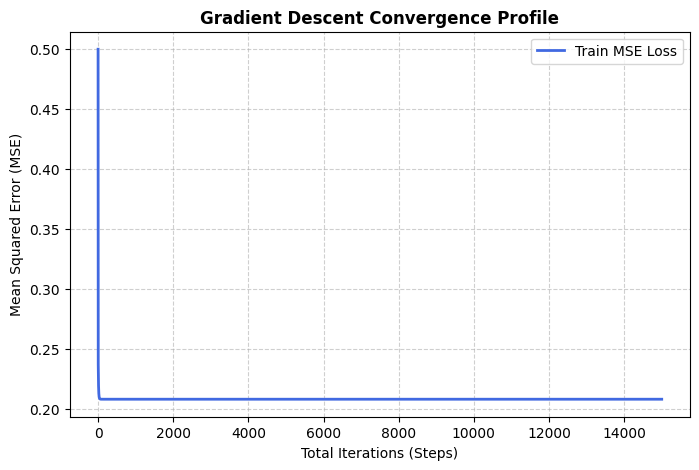

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_708/2182674775.py:24: RuntimeWarning: overflow encountered in square
  return (0.5 * (1 / X.shape[0])) * np.sum(((X @ Q) - Y) ** 2)
/tmp/ipykernel_708/2182674775.py:44: RuntimeWarning: overflow encountered in square
  if (np.sum((Q - verify_analytic) ** 2) <= epsilon_rad) and (cnt == 0):
/tmp/ipykernel_708/2182674775.py:16: RuntimeWarning: overflow encountered in matmul
  return (1 / X.shape[0]) * (X.T @ ((X @ Q) - Y))
/tmp/ipykernel_708/2182674775.py:16: RuntimeWarning: invalid value encountered in matmul
  return (1 / X.shape[0]) * (X.T @ ((X @ Q) - Y))
/tmp/ipykernel_708/2182674775.py:51: RuntimeWarning: invalid value encountered in subtract
  Q -= lr * grad(X, Y, Q)


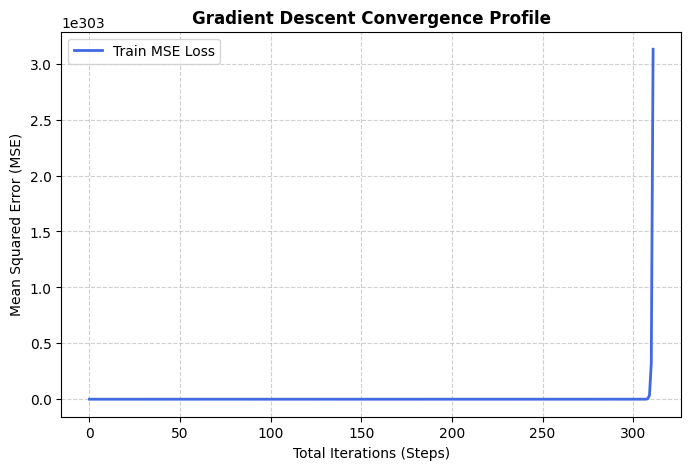

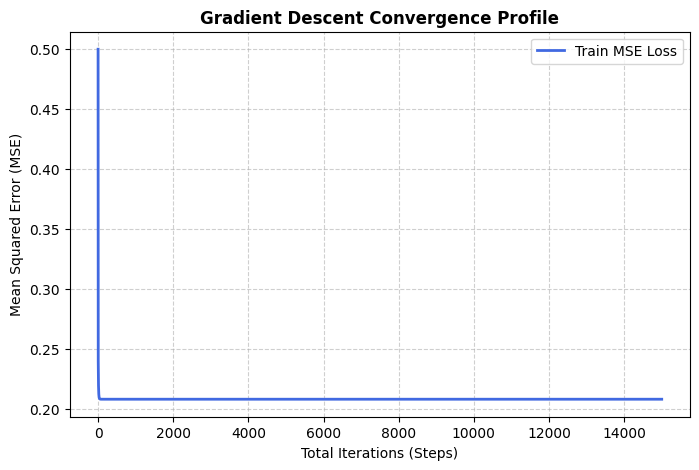

In [ ]:
# Based on this, let's try out different combinations of lr to see how;
# The GD algorithm behaves under each selected lr.
# Our 1st lr will be inside the interval of (0, 2 / eigen_max)
# Our 2nd lr will be a bit lesser than (2 / eigen_min)
# Our 3rd lr will be a bit greater than (2 / eigen_max)
# Our 4th lr will be the mathematically fastest / most optimal lr = (2 / (eigen_max + eigen_min)).
# The 4th lr can be derived using convex arguments and minimax inequalities.
# We set a random seed to 32 for reproducibility of results.
np.random.seed(32)
# We put the sample lr's in a list.
lr_list = [np.random.uniform(0.04, 2 / (max_eigen)), 2, (2 / (max_eigen + min_eigen))]
# We will store the Q's so generated for further use
Q_list = []
steps_list = []
for i in lr_list:
  Q_i, tsteps_i = linear_regression_bgd(X_train, Y_train, i, 5000, 3, verify_analytic = Q_optimal)
  Q_list.append(Q_i)
  steps_list.append(tsteps_i)

In [ ]:
print(steps_list)

[149, 15000, 131]


In [ ]:
# Now, we will try running Locally weighted regression.
# We define the weights function before this in terms of the hyperparameter tau;
# Since that will be an integral part of our run.
def weights(X, x_q, tau):
  # We use the Gaussian kernel w.r.t. the query point x_q along with hyperparameter tau;
  # To return a column vector of m entries as our weight vector.
  return np.exp(-np.sum((X - x_q.T) ** 2, axis = 1, keepdims = True) / (2 * (tau ** 2)))
# Now we write the bgd function with lwr.
def lwr_bgd(X, Y, lr, iters, epochs, x_q, tau, verify_analytic = None):
  # First initialize the parameter tensor at the origin.
  # Now, we also initialize the weighted column vector for further use.
  Q = np.zeros((X.shape[1], 1))
  W = weights(X, x_q, tau)
  # We calculate the Hessian of the cost function for comparing results from our experimentation.
  H_lwr = X.T @ (X * W)
  # A sub-matrix we use to calculate the loss and gradient.
  # We defined this earlier for convenience.
  Targ_lwr = X.T @ (W * Y)
  # Defining the gradient function using the Hessian and the other sub - matrix.
  def grad(X, Y, Q, W):
    return (1 / X.shape[0]) * ((H_lwr @ Q) - Targ_lwr)
  # We want to record how our loss changes as our bgd descends into its minimum.
  loss_history = []
  # Another submatrix we need for our calculation.
  YTY_lwr = np.sum(Y * Y * W)
  # This is the function to compute the loss via the cost function. A standard computation.
  def compute_loss(X, Y, Q, W):
    return ((1 / (2 * X.shape[0])) * ((Q.T @ H_lwr @ Q) - (Q.T @ Targ_lwr) - (Targ_lwr.T @ Q) + YTY_lwr))[0, 0]
  # Just like before, we want to note the exact point at which we reach the epsilon ballpark.
  # The no. of iterations required for that will give us a measure of how fast the lr was.
  cnt = 0
  final_steps = epochs * iters
  # Run the training loop.
  for i in range(epochs):
    # We have a set no. of iterations over an epoch which we try and run through.
    for j in range(iters):
      # This is to check when the gradient descent reaches or crosses the epsilon threshold.
      if verify_analytic is None:
        loss_history.append(compute_loss(X, Y, Q, W))
        Q -= lr * grad(X, Y, Q, W)
      else:
        epsilon_rad = 1e-5
        # Standard gradient descent update rule.
        if (np.sum((Q - verify_analytic) ** 2) <= epsilon_rad) and (cnt == 0):
          loss_history.append(compute_loss(X, Y, Q, W))
          final_steps = (i * iters) + (j + 1)
          cnt = 1
          Q -= lr * grad(X, Y, Q, W)
        else:
          loss_history.append(compute_loss(X, Y, Q, W))
          Q -= lr * grad(X, Y, Q, W)
  # Return the final values.
  return Q, final_steps, loss_history

/tmp/ipykernel_708/4070736605.py:28: RuntimeWarning: overflow encountered in matmul
  return ((1 / (2 * X.shape[0])) * ((Q.T @ H_lwr @ Q) - (Q.T @ Targ_lwr) - (Targ_lwr.T @ Q) + YTY_lwr))[0, 0]
/tmp/ipykernel_708/4070736605.py:44: RuntimeWarning: overflow encountered in square
  if (np.sum((Q - verify_analytic) ** 2) <= epsilon_rad) and (cnt == 0):
/tmp/ipykernel_708/4070736605.py:21: RuntimeWarning: overflow encountered in matmul
  return (1 / X.shape[0]) * ((H_lwr @ Q) - Targ_lwr)
/tmp/ipykernel_708/4070736605.py:28: RuntimeWarning: invalid value encountered in matmul
  return ((1 / (2 * X.shape[0])) * ((Q.T @ H_lwr @ Q) - (Q.T @ Targ_lwr) - (Targ_lwr.T @ Q) + YTY_lwr))[0, 0]
/tmp/ipykernel_708/4070736605.py:21: RuntimeWarning: invalid value encountered in matmul
  return (1 / X.shape[0]) * ((H_lwr @ Q) - Targ_lwr)
/tmp/ipykernel_708/4070736605.py:51: RuntimeWarning: invalid value encountered in subtract
  Q -= lr * grad(X, Y, Q, W)


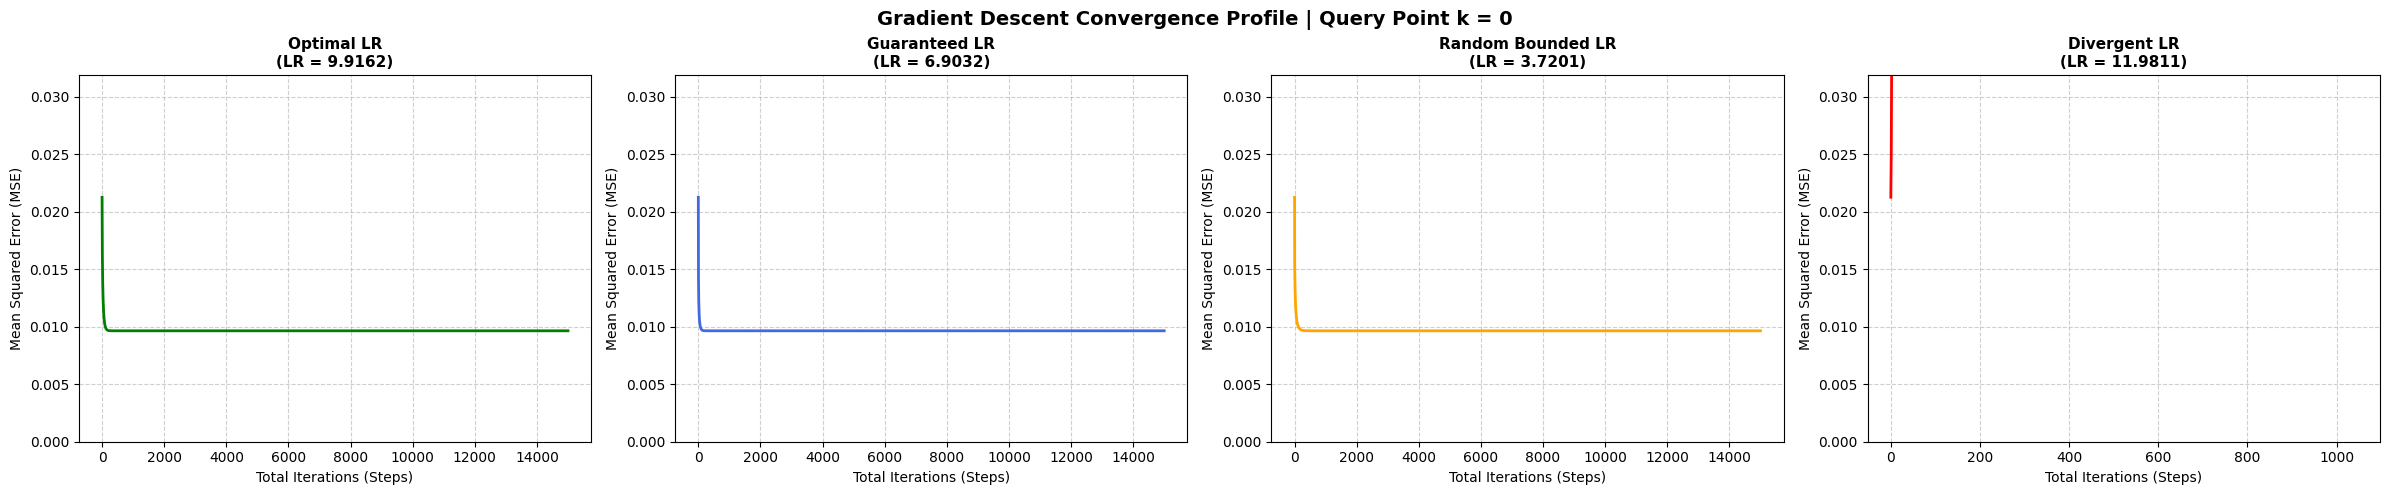

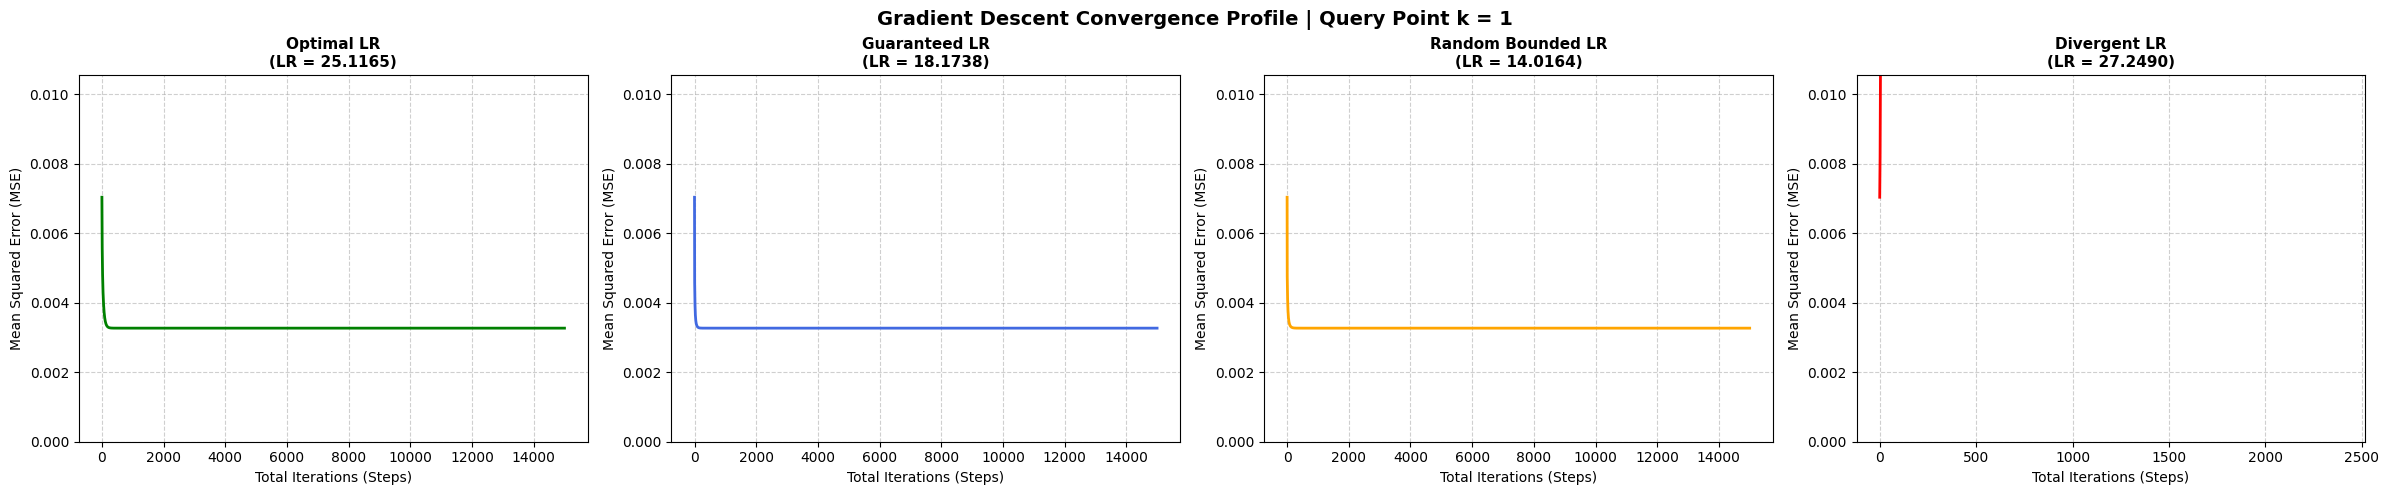

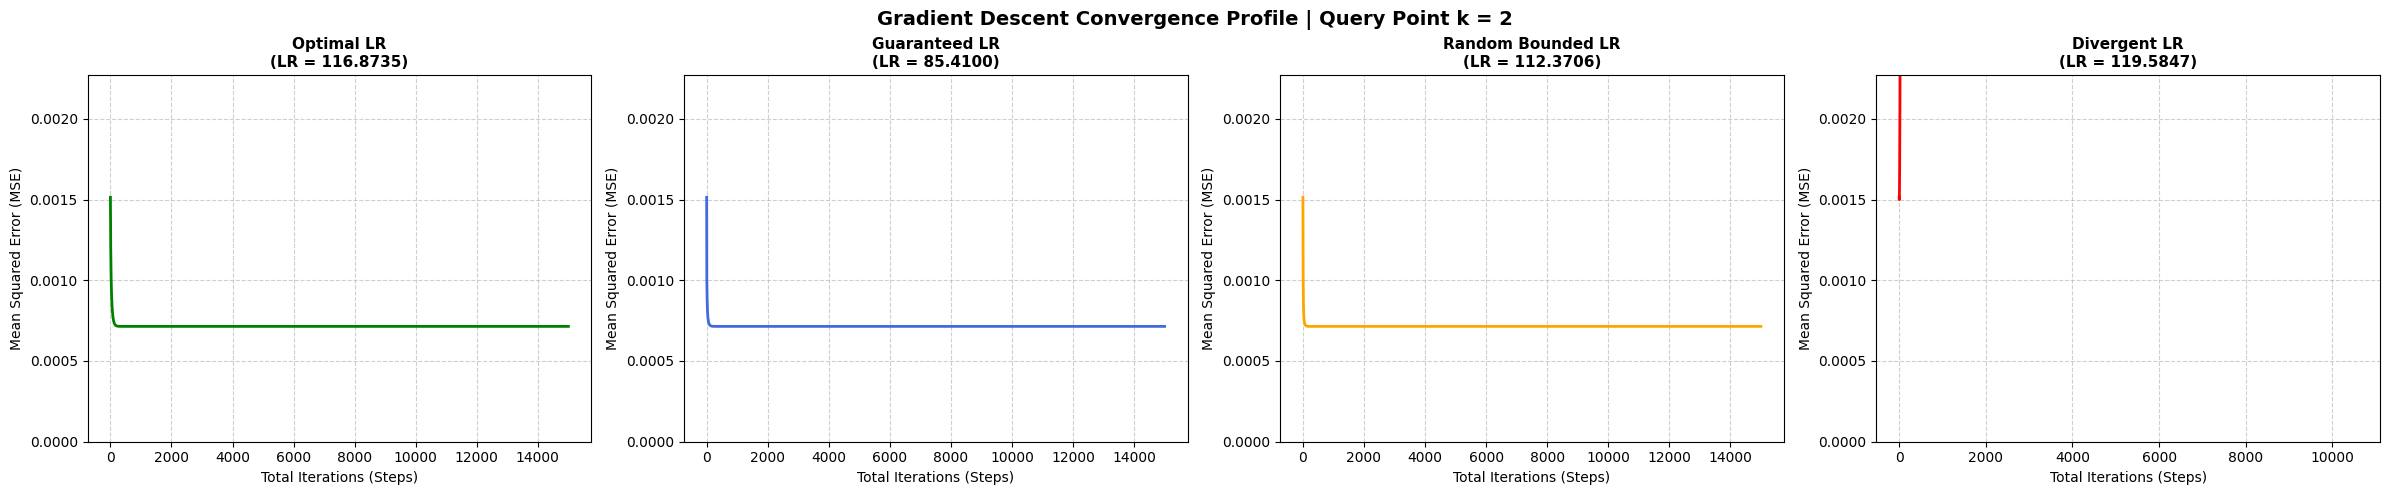

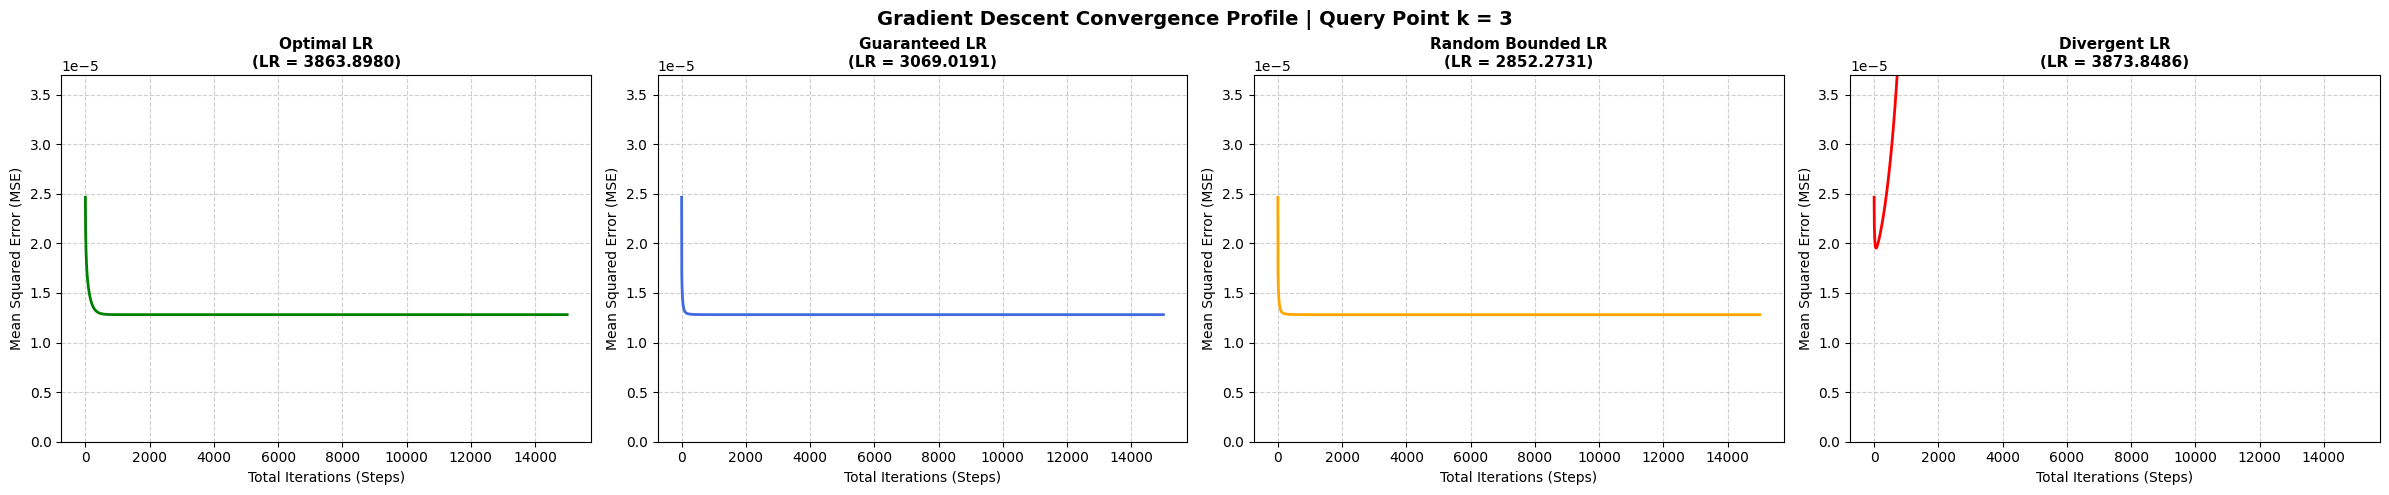

/tmp/ipykernel_708/4070736605.py:28: RuntimeWarning: invalid value encountered in subtract
  return ((1 / (2 * X.shape[0])) * ((Q.T @ H_lwr @ Q) - (Q.T @ Targ_lwr) - (Targ_lwr.T @ Q) + YTY_lwr))[0, 0]


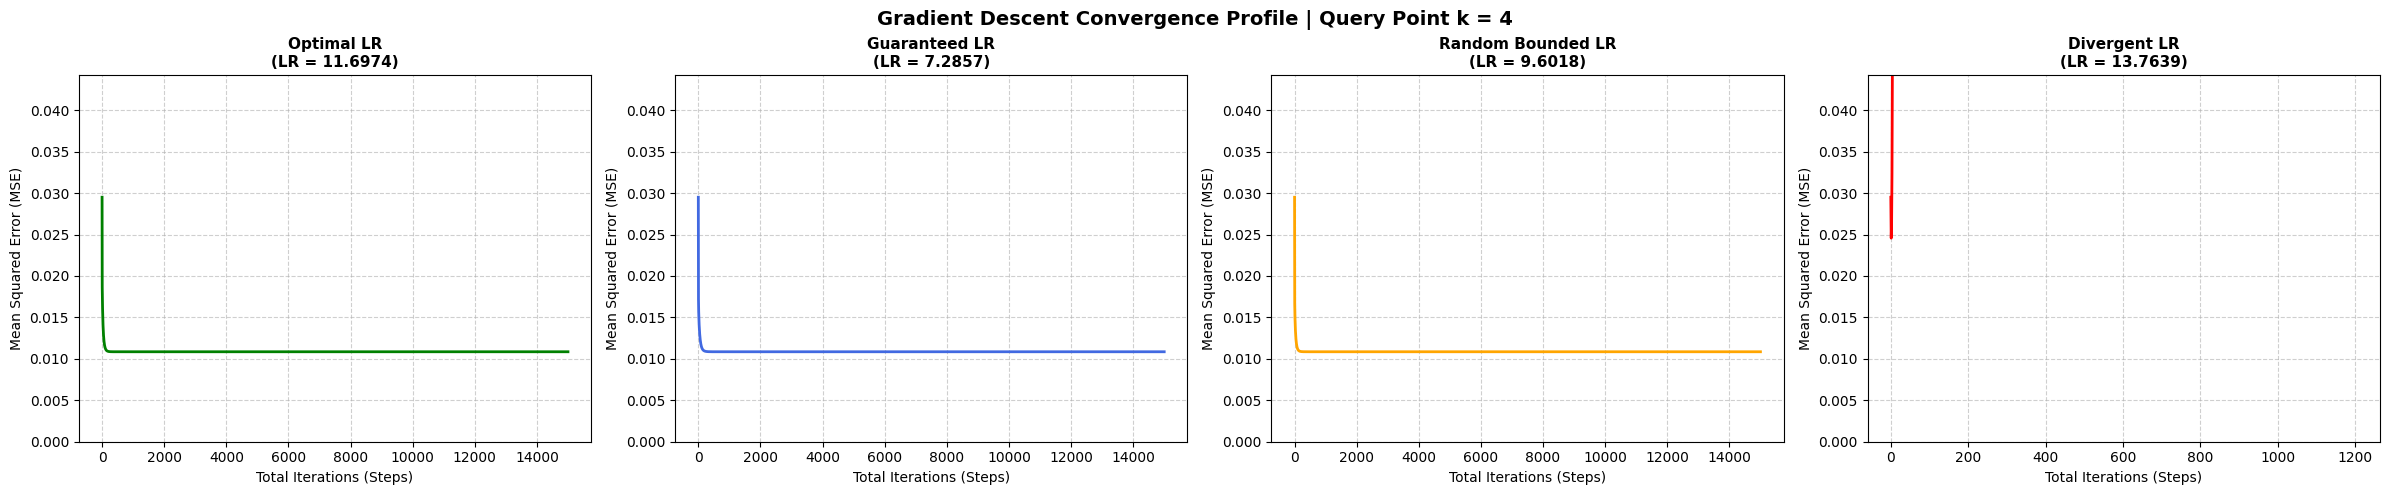

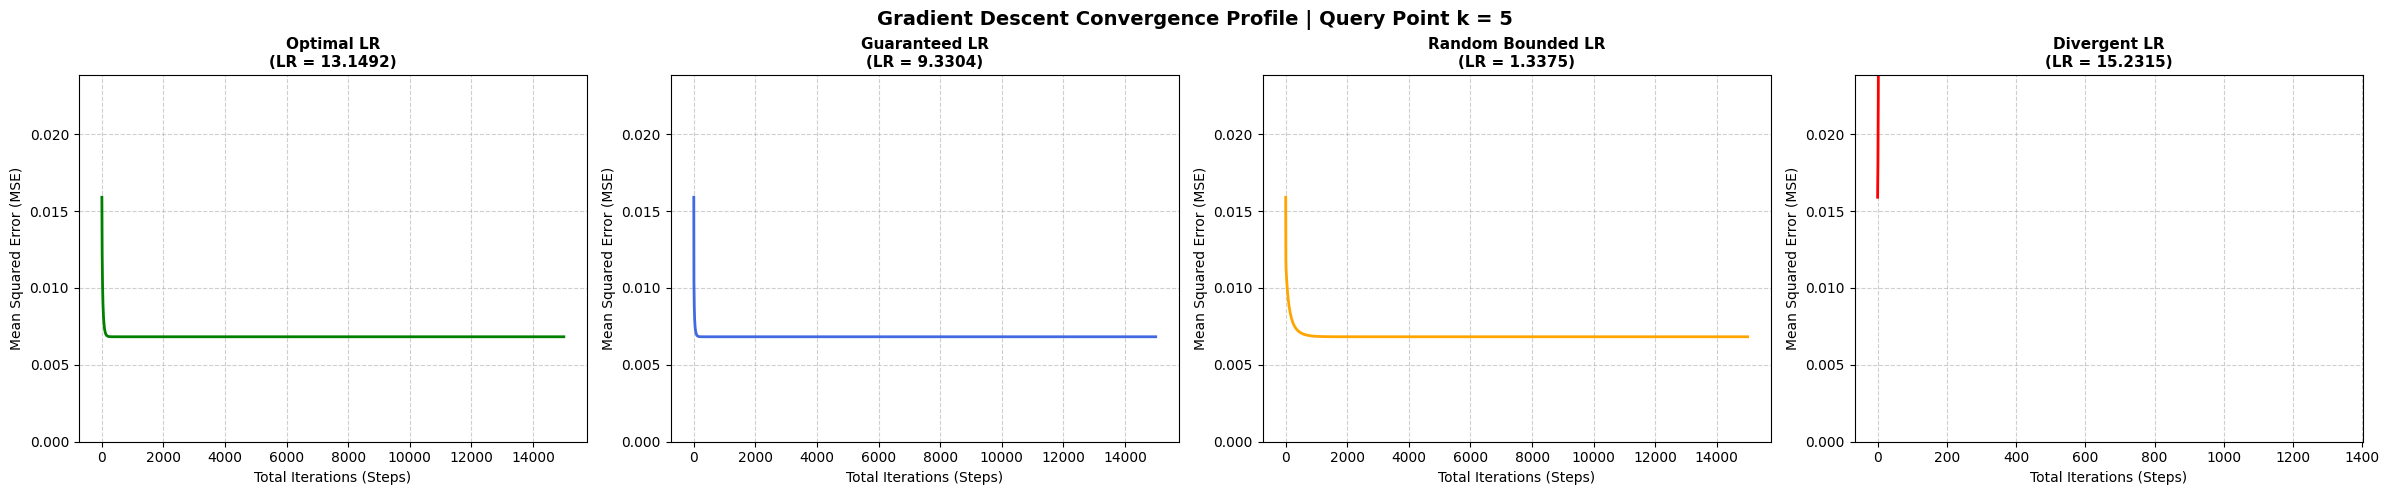

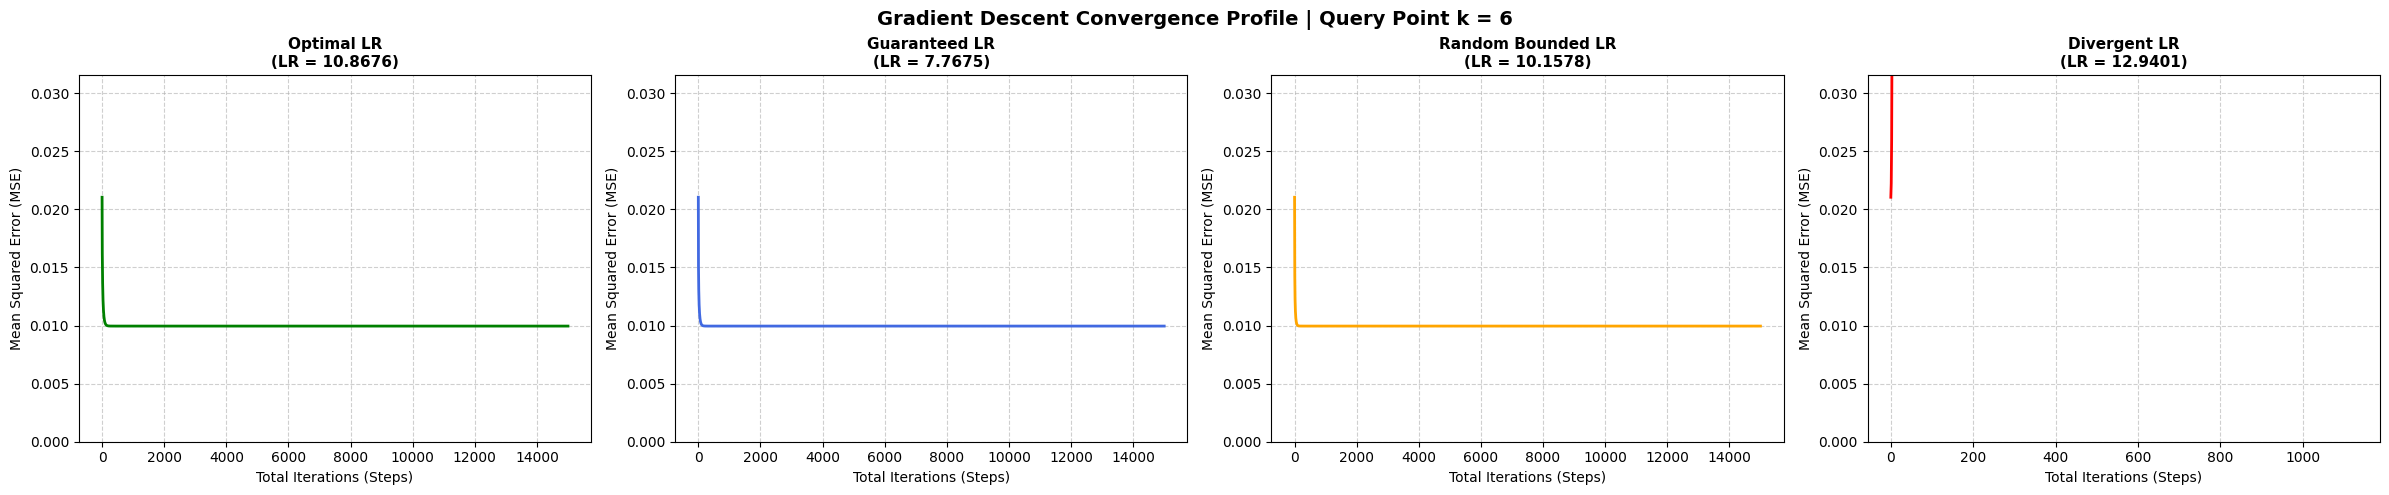

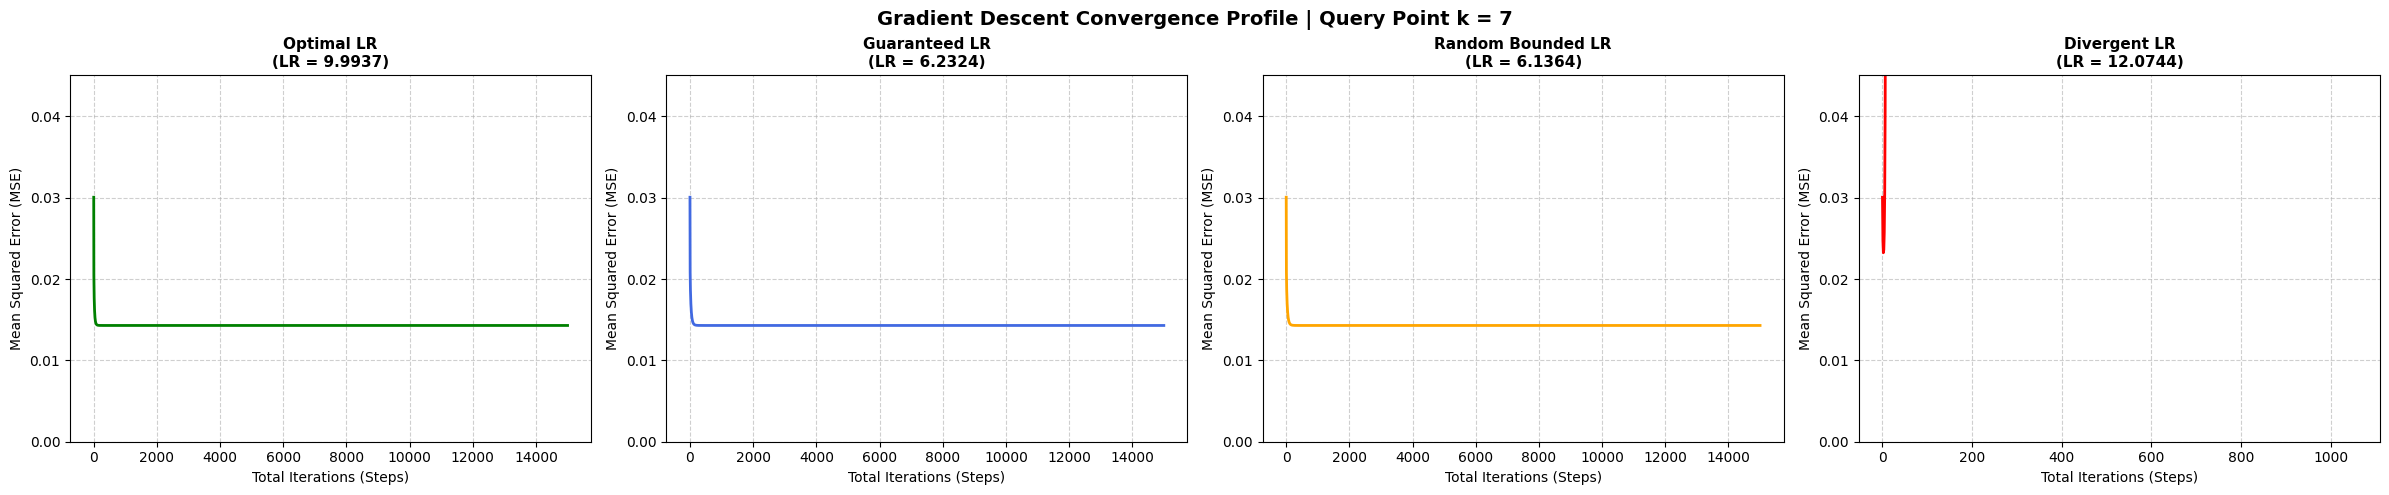

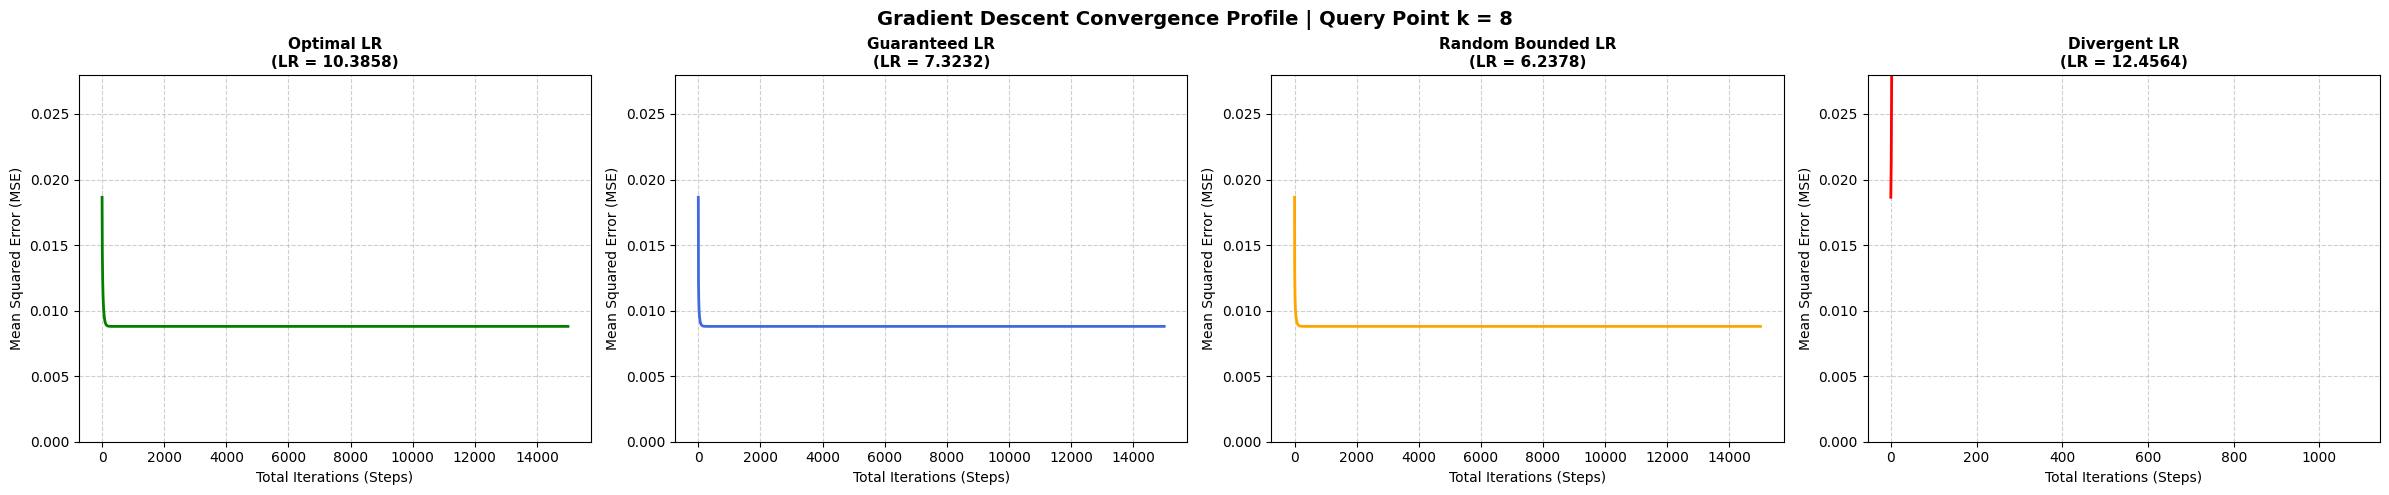

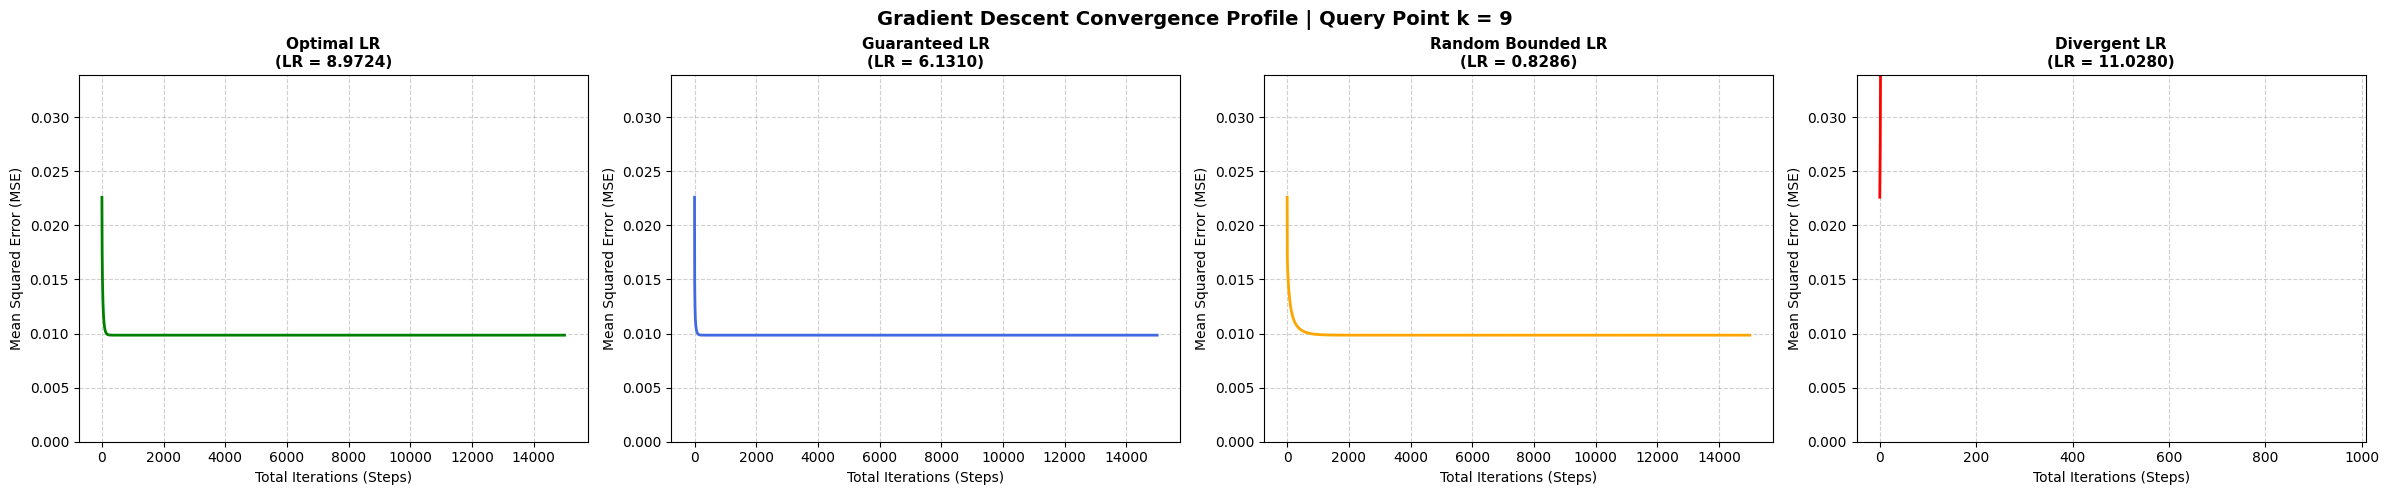

In [ ]:
# We fix tau at a convenient value for analyzing convergence.
tau_fixed = 1
# We take 10 queries from the validation dataset to run our lwr on.
for k, x_q in enumerate(X_val):
  if k == 10:
    break
  # We reshape each row vector into a column vector to match dimensions.
  x_q = X_val[k].reshape(-1, 1)
  # Calculate the weights induced via the query point.
  W = weights(X_train, x_q, tau_fixed)
  # We calculate the maximum and minimum eigenvalues of Hessian here solely for analysis.
  eigenvalues = np.linalg.eigvalsh(((W * X_train).T @ X_train) / X_train.shape[0])
  # We compare how the various lr's as set by us fare w.r.t. the analytical solution.
  max_eigen_lwr = eigenvalues[-1]
  min_eigen_lwr = eigenvalues[0]
  # This is the analytical solution.
  Q_optimal_lwr = np.linalg.inv((W * X_train).T @ X_train) @ ((W * X_train).T @ Y_train)

  # Here we have our choices of lr that we set.
  # First one is the optimal lr that gives us the fastest convergence.
  # Worst case scenario, its computation requires O(n^3) time.
  lr_opt = 2 / (max_eigen_lwr + min_eigen_lwr)
  # Second one is the lr that guarantees us convergence no matter what, although not as fast.
  # What's the difference in the first lr and this one then? They both guarantee convergence no?
  # However, computation of lr for this requires O(mn) complexity, which in many cases can be less taxing. Proof for this given in our report.
  lr_guaranteed = (2 * X_train.shape[0]) / (np.sum(np.sum(X_train ** 2, axis = 1, keepdims = True) * W, axis = 0))
  # The third lr is simply supposed to be a random lr selected from the guaranteed convergence interval [0, 2/lambmax].
  lr_bound_guaranteed = np.random.uniform(0, 2 / max_eigen_lwr)
  # This one is to show how the dataset explodes as we increase lr over the maximum convergence limit.
  lr_divergent = (2 / max_eigen_lwr) + 2
  # We perform a sweep over these lr's per querypoint to show how the loss curve behaves over the iterations of bgd.
  lr_list_lwr = [lr_opt, lr_guaranteed, lr_bound_guaranteed, lr_divergent]
  lr_names = ['Optimal LR', 'Guaranteed LR', 'Random Bounded LR', 'Divergent LR']
  lr_colors = ['green', 'royalblue', 'orange', 'red']
  # We record what the final parameter tensors in each of these are, as well as how many steps taken and the final losses.
  Q_list_lwr = []
  steps_list_lwr = []
  all_losses = []
  # The for loop that runs the sweep.
  for i in lr_list_lwr:
    Q_i, tsteps_i, loss_i = lwr_bgd(X_train, Y_train, i, 5000, 3, x_q, tau_fixed, verify_analytic = Q_optimal_lwr)
    Q_list_lwr.append(Q_i)
    steps_list_lwr.append(tsteps_i)
    all_losses.append(loss_i)
  # This particular pipeline was generate by GPT in order to plot how the lr's behave per query point.
  # We will have 4 graphs for each lr visible per query point, hence 40 graphs in total.
  fig, axes = plt.subplots(1, 4, figsize = (24, 5))
  fig.suptitle(f'Gradient Descent Convergence Profile | Query Point k = {k}', fontsize = 14, fontweight = 'bold')
  for idx, loss_arr in enumerate(all_losses):
    lr_val = float(np.array(lr_list_lwr[idx]).item())
    axes[idx].plot(loss_arr, color=lr_colors[idx], linewidth=2)
    axes[idx].set_title(f'{lr_names[idx]}\n(LR = {lr_val:.4f})', fontsize = 11, fontweight = 'bold')
    axes[idx].set_xlabel('Total Iterations (Steps)', fontsize = 10)
    axes[idx].set_ylabel('Mean Squared Error (MSE)', fontsize = 10)
    axes[idx].set_ylim(0, all_losses[0][0] * 1.5)
    axes[idx].grid(True, linestyle = '--', alpha = 0.6)
  plt.tight_layout()
  plt.subplots_adjust(top = 0.85)
  plt.show()